# 04 — Cleveland: how big are the differences, and could they be chance?

**Phase 3, Step 2.** Notebook 03 *described* differences between patients
with and without heart disease. Its "strong / weak" labels were visual
judgements. Here every one of the 13 predictors gets three numbers:

1. **An effect size**: how big the difference is, on a scale that doesn't
   depend on the sample size.
2. **A 95% confidence interval** for that effect size: the range of values
   consistent with the data. A narrow interval means the estimate is precise.
3. **A p-value, corrected for multiple testing**: how surprising a difference
   this large would be if the variable had no real link to disease.

The effect size is the headline. A p-value only says whether a difference is
distinguishable from zero, not whether it is large enough to matter.

Still one variable at a time, and still referred patients only (see notebook 03).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from clean_data import load_clean  # noqa: E402

df = load_clean()
cle = df[df["site"] == "cleveland"].copy()
disease = cle["disease"].astype(bool).to_numpy()

N_BOOT = 2000          # bootstrap resamples for confidence intervals
rng = np.random.default_rng(42)   # fixed seed: results are reproducible
ALPHA = 0.05

NUMERIC = {"age": "Age", "resting_bp": "Resting blood pressure", "cholesterol": "Cholesterol",
           "max_heart_rate": "Max heart rate", "st_depression": "ST depression"}
CATEGORICAL = {"sex": "Sex", "chest_pain_type": "Chest pain type",
               "exercise_angina": "Exercise-induced angina", "st_slope": "ST segment slope",
               "major_vessels": "Major vessels coloured", "thallium_result": "Thallium stress test",
               "resting_ecg": "Resting ECG", "fasting_blood_sugar_gt_120": "Fasting blood sugar > 120"}

## 1. Numeric measurements

**Test: Mann–Whitney U.** It ranks all patients on the measurement and asks
whether one group's ranks are systematically higher. Unlike the t-test it
doesn't assume bell-shaped data, which matters here: ST depression piles up at
0 and cholesterol has a long right tail.

**Effect size: probability of superiority (PS).** Pick one patient with
disease and one without at random. PS is the chance the patient with disease
has the higher value (ties count half).
- PS = 0.5: no difference at all.
- PS = 0.7: the patient with disease is higher 70% of the time.
- PS = 0.3: the patient with disease is *lower* 70% of the time.

It comes straight from the Mann–Whitney statistic (PS = U / (n₁·n₂)), so the
test and the effect size tell one consistent story. The median difference is
also given in the original units, which is easier to picture.

**Confidence intervals: bootstrap.** Resample the patients with replacement
2,000 times (keeping group sizes fixed), recompute the statistic each time,
and take the middle 95% of the results. No formula or distribution
assumption needed.

In [2]:
def boot_ci(values):
    return np.percentile(values, [2.5, 97.5])

num_rows = []
for col, label in NUMERIC.items():
    x = cle[col].astype(float).to_numpy()
    ok = ~np.isnan(x)
    a, b = x[ok & disease], x[ok & ~disease]          # a = disease, b = no disease
    res = stats.mannwhitneyu(a, b, alternative="two-sided")
    ps = res.statistic / (len(a) * len(b))
    ps_boot, md_boot = [], []
    for _ in range(N_BOOT):
        ra = rng.choice(a, len(a)); rb = rng.choice(b, len(b))
        ps_boot.append(stats.mannwhitneyu(ra, rb).statistic / (len(a) * len(b)))
        md_boot.append(np.median(ra) - np.median(rb))
    num_rows.append({"variable": label, "type": "numeric", "test": "Mann–Whitney U",
                     "effect": "prob. of superiority", "estimate": ps,
                     "ci_low": boot_ci(ps_boot)[0], "ci_high": boot_ci(ps_boot)[1],
                     "median diff": np.median(a) - np.median(b),
                     "median diff CI": "{:.1f} to {:.1f}".format(*boot_ci(md_boot)),
                     "p": res.pvalue})
num_res = pd.DataFrame(num_rows)
num_res.drop(columns=["type", "test", "effect"]).round(3)

,variable,estimate,ci_low,ci_high,median diff,median diff CI,p
0,Age,0.637,0.573,0.701,6.0,3.0 to 7.0,0.000
1,Resting blood pressure,0.574,0.511,0.638,0.0,0.0 to 7.0,0.026
2,Cholesterol,0.570,0.507,0.634,14.5,2.5 to 28.0,0.035
3,Max heart rate,0.255,0.204,0.311,-19.0,-24.0 to -15.0,0.000
4,ST depression,0.735,0.679,0.791,1.2,0.8 to 1.6,0.000


## 2. Categorical measurements

**Test: chi-square test of independence.** It compares the counts in each
category × diagnosis cell with the counts you would expect if the category had
nothing to do with disease. The usual formula for its p-value is an
approximation that becomes unreliable when an expected count falls below 5.
**Resting ECG** has that problem: the "ST-T abnormality" category has only 4
patients. For any such table the p-value comes from a **permutation test**
instead: shuffle the disease labels 9,999 times and see how often a chi-square
as large as the real one appears by chance.

**Effect size: Cramér's V**, from 0 (disease rate identical in every category)
to 1 (category perfectly determines disease). As a rough guide for a two-row
table, 0.1 is small, 0.3 medium and 0.5 large. One quirk: V can't go below 0,
so with finite data its estimate and interval sit slightly above 0 even when
there's no real association. Read a small V with a wide interval touching near
0 as "no clear association". The disease-rate range across categories (from
notebook 03) is shown alongside because it's easier to picture.

In [3]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False).statistic
    n = table.sum()
    k = min(table.shape) - 1
    return np.sqrt(chi2 / (n * k))

cat_rows = []
for col, label in CATEGORICAL.items():
    sub = cle.dropna(subset=[col])
    table = pd.crosstab(sub[col], sub["disease"]).to_numpy()
    expected = stats.contingency.expected_freq(table)
    small = (expected < 5).any()
    if small:
        res = stats.chi2_contingency(table, correction=False,
                                     method=stats.PermutationMethod(n_resamples=9999, rng=0))
    else:
        res = stats.chi2_contingency(table, correction=False)
    v = cramers_v(table)
    # bootstrap V by resampling patients
    cats, dis = sub[col].to_numpy(), sub["disease"].astype(bool).to_numpy()
    v_boot = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(sub), len(sub))
        t = pd.crosstab(cats[idx], dis[idx]).to_numpy()
        v_boot.append(cramers_v(t) if t.shape[1] == 2 and t.shape[0] > 1 else np.nan)
    rates = sub.groupby(col, observed=True)["disease"].mean() * 100
    cat_rows.append({"variable": label, "type": "categorical",
                     "test": "chi-square (permutation)" if small else "chi-square",
                     "effect": "Cramér's V", "estimate": v,
                     "ci_low": np.nanpercentile(v_boot, 2.5), "ci_high": np.nanpercentile(v_boot, 97.5),
                     "disease rate range": f"{rates.min():.0f}%–{rates.max():.0f}%",
                     "min expected count": round(expected.min(), 1), "p": res.pvalue})
cat_res = pd.DataFrame(cat_rows)
cat_res.drop(columns=["type", "effect"]).round(3)

,variable,test,estimate,ci_low,ci_high,disease rate range,min expected count,p
0,Sex,chi-square,0.277,0.169,0.380,26%–55%,44.5,0.000
1,Chest pain type,chi-square,0.520,0.428,0.615,18%–73%,10.6,0.000
2,Exercise-induced angina,chi-square,0.432,0.334,0.531,31%–77%,45.4,0.000
3,ST segment slope,chi-square,0.389,0.290,0.498,25%–65%,9.6,0.000
4,Major vessels coloured,chi-square,0.490,0.402,0.588,26%–85%,9.2,0.000
5,Thallium stress test,chi-square,0.526,0.437,0.625,22%–76%,8.3,0.000
6,Resting ECG,chi-square (permutation),0.182,0.081,0.300,37%–75%,1.8,0.004
7,Fasting blood sugar > 120,chi-square,0.025,0.002,0.145,45%–49%,20.6,0.660


## 3. Correcting for 13 tests at once

With a 0.05 threshold, each test has a 5% chance of a false alarm when there
is no real difference. Run 13 tests and the chance of *at least one* false
alarm is about 1 − 0.95¹³ ≈ 49%. The **Holm correction** fixes this: sort the
p-values from smallest to largest, compare the smallest with 0.05/13, the next
with 0.05/12, and so on, stopping at the first one that fails. It keeps the
overall false-alarm chance at 5% and is never less powerful than the simpler
Bonferroni correction (every p-value against 0.05/13).

In [4]:
def holm(pvals):
    p = np.asarray(pvals)
    order = np.argsort(p)
    m = len(p)
    adjusted = np.empty(m)
    running_max = 0.0
    for rank, i in enumerate(order):
        running_max = max(running_max, min(1.0, (m - rank) * p[i]))
        adjusted[i] = running_max   # adjusted p-values never decrease with rank
    return adjusted

results = pd.concat([num_res, cat_res], ignore_index=True)
results["p (Holm)"] = holm(results["p"])
results["significant"] = results["p (Holm)"] < ALPHA

def fmt_p(p):
    return "< 0.0001" if p < 1e-4 else f"{p:.4f}"

summary = results.assign(
    **{"effect size (95% CI)": results.apply(
        lambda r: f"{r['estimate']:.2f} ({r['ci_low']:.2f}–{r['ci_high']:.2f})", axis=1),
       "p": results["p"].map(fmt_p), "p (Holm)": results["p (Holm)"].map(fmt_p)}
)[["variable", "effect", "effect size (95% CI)", "test", "p", "p (Holm)", "significant"]]
summary.to_csv(ROOT / "reports" / "cleveland_tests.csv", index=False)
summary

,variable,effect,effect size (95% CI),test,p,p (Holm),significant
0,Age,prob. of superiority,0.64 (0.57–0.70),Mann–Whitney U,< 0.0001,0.0002,True
1,Resting blood pressure,prob. of superiority,0.57 (0.51–0.64),Mann–Whitney U,0.0260,0.0779,False
2,Cholesterol,prob. of superiority,0.57 (0.51–0.63),Mann–Whitney U,0.0354,0.0779,False
3,Max heart rate,prob. of superiority,0.25 (0.20–0.31),Mann–Whitney U,< 0.0001,< 0.0001,True
4,ST depression,prob. of superiority,0.74 (0.68–0.79),Mann–Whitney U,< 0.0001,< 0.0001,True
5,Sex,Cramér's V,0.28 (0.17–0.38),chi-square,< 0.0001,< 0.0001,True
6,Chest pain type,Cramér's V,0.52 (0.43–0.62),chi-square,< 0.0001,< 0.0001,True
7,Exercise-induced angina,Cramér's V,0.43 (0.33–0.53),chi-square,< 0.0001,< 0.0001,True
8,ST segment slope,Cramér's V,0.39 (0.29–0.50),chi-square,< 0.0001,< 0.0001,True
9,Major vessels coloured,Cramér's V,0.49 (0.40–0.59),chi-square,< 0.0001,< 0.0001,True


The full table is also saved as `reports/cleveland_tests.csv`.

## 4. The effect sizes in one picture

Each dot is the estimate and each line its 95% confidence interval. **Filled
dots** remain significant after the Holm correction; **hollow dots** don't.
The two panels use different effect-size scales, so compare within a panel,
not across.

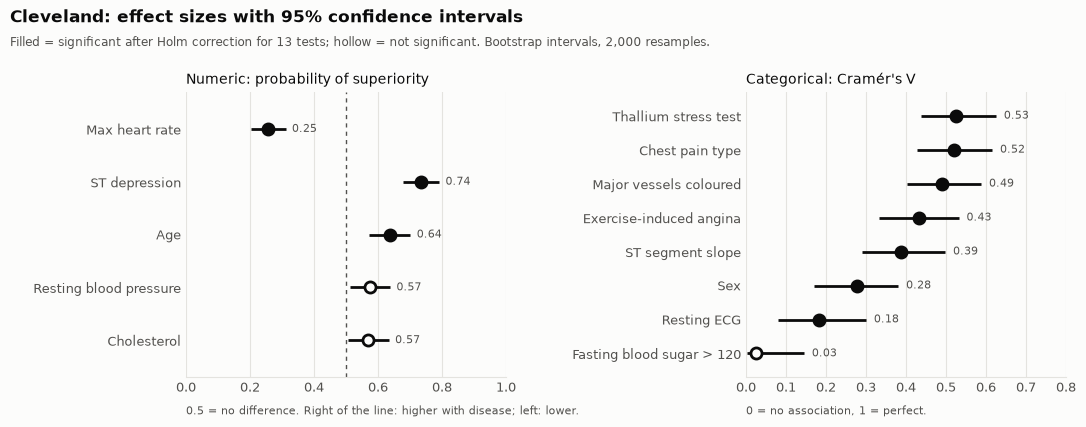

In [5]:
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6),
                               gridspec_kw={"width_ratios": [1, 1], "wspace": 0.75})
panels = [(ax1, results[results["type"] == "numeric"], 0.5, (0, 1),
           "Numeric: probability of superiority",
           "0.5 = no difference. Right of the line: higher with disease; left: lower."),
          (ax2, results[results["type"] == "categorical"], None, (0, 0.8),
           "Categorical: Cramér's V", "0 = no association, 1 = perfect.")]
for ax, sub, ref, xlim, title, note in panels:
    sub = sub.sort_values("estimate", key=lambda s: (s - 0.5).abs() if ref else s)
    y = np.arange(len(sub))
    if ref is not None:
        ax.axvline(ref, color=INK_2, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
    ax.hlines(y, sub["ci_low"], sub["ci_high"], color=INK, linewidth=2, zorder=2)
    for yi, (_, r) in zip(y, sub.iterrows()):
        ax.scatter(r["estimate"], yi, s=64, zorder=3, linewidths=2, edgecolors=INK,
                   facecolors=INK if r["significant"] else SURFACE)
        ax.text(r["ci_high"] + 0.02, yi, f"{r['estimate']:.2f}", va="center",
                fontsize=8, color=INK_2)
    ax.set_yticks(y, sub["variable"])
    ax.set_xlim(*xlim)
    ax.set_ylim(-0.7, len(sub) - 0.3)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_title(title, loc="left", fontsize=10, color=INK)
    ax.text(0, -0.13, note, transform=ax.transAxes, fontsize=8, color=INK_2)
fig.suptitle("Cleveland: effect sizes with 95% confidence intervals", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.9, "Filled = significant after Holm correction for 13 tests; "
         "hollow = not significant. Bootstrap intervals, 2,000 resamples.",
         fontsize=8.5, color=INK_2)
fig.subplots_adjust(left=0.17, right=0.97, top=0.8, bottom=0.18)
fig.savefig(ROOT / "reports" / "figures" / "cleveland_effect_sizes.png", dpi=200)
plt.show()

## 5. What the numbers say

**10 of the 13 predictors differ between the groups by more than chance would
plausibly produce, even after correcting for 13 tests.**

**The largest differences:**

| Predictor | Effect size (95% CI) | In plain terms |
|---|---|---|
| Thallium stress test | V = 0.53 (0.44–0.62) | large |
| Chest pain type | V = 0.52 (0.43–0.62) | large (driven by asymptomatic patients, see notebook 03) |
| Major vessels coloured | V = 0.49 (0.40–0.59) | large-to-medium |
| Exercise-induced angina | V = 0.43 (0.33–0.53) | medium |
| ST segment slope | V = 0.39 (0.29–0.50) | medium |
| ST depression | PS = 0.74 (0.68–0.79) | a patient with disease has the higher value 74% of the time |
| Max heart rate | PS = 0.25 (0.20–0.31) | a patient with disease has the *higher* rate only 25% of the time; median 19 bpm lower (15 to 24) |

**Smaller but clear:** age (PS 0.64; median 6 years older, 3 to 7), sex
(V 0.28) and resting ECG (V 0.18, small).

**Three lessons from the borderline cases:**

1. **Cholesterol and resting blood pressure show why correction matters.**
   Each has an uncorrected p below 0.05 (0.035 and 0.026). Tested alone,
   either would be called "significant". After the Holm correction both land
   at 0.078, not significant. Their effect sizes (PS 0.57) are small either
   way. The honest conclusion: *at most a small difference in this referred
   sample*, not "no difference" and not "a real risk factor confirmed".
2. **Why do their intervals (0.51–0.64) exclude 0.5 if they're not
   significant?** Each 95% interval is built for one variable on its own; it
   isn't corrected for 13 comparisons. The corrected p-value is the stricter
   standard. Both point the same way: any difference is small, and the
   evidence for it is borderline.
3. **Fasting blood sugar shows what "not significant" does and doesn't
   mean.** V = 0.03 with an interval reaching 0.14. That rules out a
   medium or large association but can't rule out a small one. Absence of
   evidence is not evidence of absence; the interval says how much absence.

**How this compares with notebook 03's visual judgements:** the "strong" group
is confirmed. Resting ECG, called "moderate" there, turns out to be small. The
"little or none" group splits: fasting blood sugar shows nothing, while
cholesterol and blood pressure are small and uncertain.

**Still true from notebook 03:** each test looks at one variable alone. Several
of these predictors overlap (exercise angina, ST depression, ST slope and max
heart rate all come from the same exercise test), so their effects can't simply
be added up. **Next step (Phase 3, Step 3):** a model that considers the
predictors together, to see which still carry information once the others are
accounted for.